### Resampling and interpolation의 흔적 감지 방법

4가지 방법으로 구성
1. ROI selection
2. signal derivative computation
3. radon transformation
4. search for periodicity

In [1]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import imageio

from scipy import ndimage
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale

In [2]:
# img = cv2.imread('human1.jpg')
# b,g,r = cv2.split(img)
# img = cv2.merge([r,g,b])
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# plt.imshow(img, cmap = 'gray')
# print(img.shape)

(863, 864)


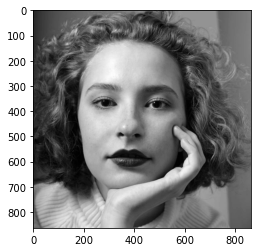

In [3]:
img = cv2.imread('human2.jpg')
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img = cv2.resize(img, dsize=(0, 0), fx=1.3, fy=1.3, interpolation=cv2.INTER_LINEAR)
print(img.shape)
plt.imshow(img, cmap='gray')

## 1. Region of Interest(ROI) selection
- typical image f(x,y); 여러개의 일관된 영역으로 구성
- 영역의 resampling 여부 조사
- R 픽셀 블록(b(x,y))으로 해당 영역 선택 (R = 128)
- 좌측상단에서 우측하단까지 수평으로 이동

In [4]:
b = []
r = 128
width, height = img.shape

for h in range(height-r):
    for w in range(width-r):
        b.append(img[w:w+r, h:h+r])  #ROI (128x128) 

In [5]:
b = np.array(b)
print(b.shape)

(540960, 128, 128)


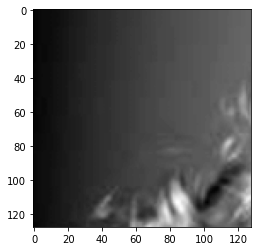

In [6]:
plt.imshow(b[0], cmap='gray')

## 2. Signal Derivative Computation

- resampling된 이미지의 covariance(공분산) 구조; 주기적 특성을 강조하기위해 b(x,y)영역의 n차 도함수 계산
- b(x, y)의 행의 인접 픽셀간의 차이를 계산하는 도함수 연산자 사용하여 수행
- 실제 실험에서는 n = 2로 설정
    - row-based signal derivative -> sobel y축으로 2번 적용
    
<img src="https://user-images.githubusercontent.com/46768752/125272520-e8ed1700-e346-11eb-8597-1f6f8a09e889.png" width="100">

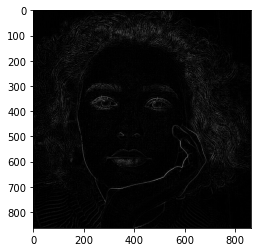

In [7]:
laplacian = cv2.Laplacian(img, cv2.CV_8U, ksize=3)

plt.imshow(laplacian, cmap='gray')

In [8]:
kernel = [1, -2, 1]

d_2 = None

## 3. Radon Transformation


<img src="https://user-images.githubusercontent.com/46768752/125269074-526b2680-e343-11eb-874d-2bae7de9ac04.png" width="600">
<img src="https://user-images.githubusercontent.com/46768752/125269171-6a42aa80-e343-11eb-97cb-1d1beb27d1a0.png" width="800">

c:\programdata\anaconda3\envs\pythonproject\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Image dtype is not float. By default radon will assume you want to preserve the range of your image (preserve_range=True). In scikit-image 0.18 this behavior will change to preserve_range=False. To avoid this warning, explicitly specify the preserve_range parameter.
  after removing the cwd from sys.path.
c:\programdata\anaconda3\envs\pythonproject\lib\site-packages\skimage\transform\radon_transform.py:91: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn('Radon transform: image must be zero outside the '


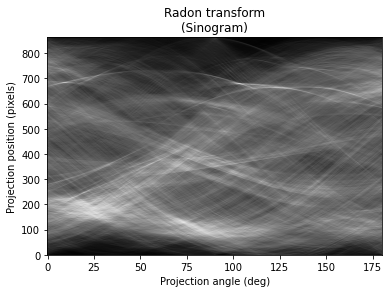

In [9]:
from skimage.transform import radon

theta = np.linspace(0., 180., max(laplacian.shape), endpoint=False)
sinogram = radon(laplacian, theta=theta)
dx, dy = 0.5 * 180.0 / max(laplacian.shape), 0.5 / sinogram.shape[0]
plt.title("Radon transform\n(Sinogram)")
plt.xlabel("Projection angle (deg)")
plt.ylabel("Projection position (pixels)")
plt.imshow(sinogram, cmap=plt.cm.Greys_r,
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
           aspect='auto')

In [10]:
sinogram.shape

(863, 864)

(863, 864)

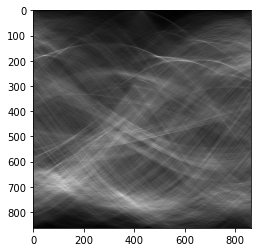

In [11]:
plt.imshow(sinogram, cmap='gray')
sinogram.shape

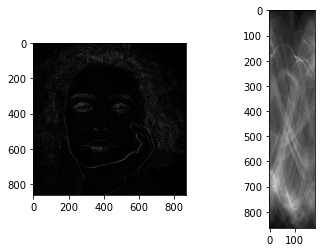

In [12]:
def DiscreteRadonTransform(image, steps):
    res = np.zeros((len(image[0]), steps), dtype='float64')
    for s in range(steps):
        rotation = ndimage.rotate(image, -s*180/steps, reshape=False).astype('float64')
        res[:, s] = sum(rotation)
    return res


sinogram = DiscreteRadonTransform(laplacian, 180)   # len(image[0])

plt.subplot(1, 2, 1)
plt.imshow(laplacian, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(sinogram, cmap='gray')
plt.show()


In [13]:
sinogram.shape

(864, 180)

(864,)


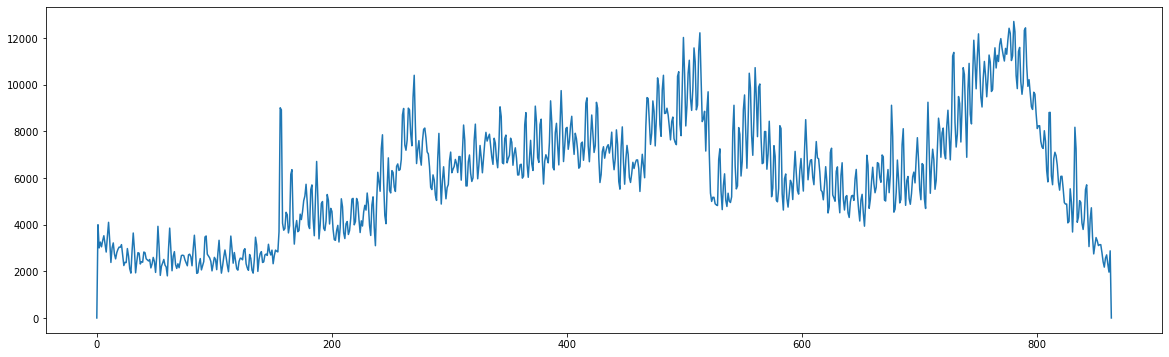

In [14]:
# radon transformation 진행결과(90도)

plt.figure(figsize=(20, 6))
plt.plot(sinogram[:,90])
print(sinogram[:,90].shape)

## 4. Search for Periodicity

<img src="https://user-images.githubusercontent.com/46768752/125269975-31570580-e344-11eb-8d30-8f3463fc4329.png" width="500">

In [15]:
p_t = sinogram[:,0]
p_t.shape[0]

864

In [16]:
# p_t 2차 미분
theta = sinogram.shape[1]
kernel = [1, -2, 1]
deri_p_t = {}
conv_ = []


for t in range(theta):
    p_t = sinogram[:,t]
    conv_ = []
    
    for i in range(p_t.shape[0]):
        if i == 0:
            conv_.append(p_t[i]*kernel[1] + p_t[i+1]*kernel[2])
        elif i == p_t.shape[0]-1:
            conv_.append(p_t[i-1]*kernel[0] + p_t[i]*kernel[1])
        else:
            conv_.append(p_t[i-1]*kernel[0] + p_t[i]*kernel[1] + p_t[i+1]*kernel[2])
        
    deri_p_t[t] = conv_

In [17]:
# p_t (180, img.shape[0])
# sinogram (img.shape[0], 180)

theta = sinogram.shape[1]
total_r_p = {}

for t in range(theta):
    p_t = deri_p_t[t]
    m = np.mean(p_t)
    r_p = []
    
    for k in range(len(p_t)):
        sum_ = 0
        for i in range(len(p_t)):
            sum_ += (p_t[(i+k)%len(p_t)]-m)*(p_t[i]-m)
        r_p.append(sum_)   # k에 대하여 r_p (len(k), len(i))
#         if sum_ > 3*m:
#             r_p.append(sum_)
#         else:
#             r_p.append(sum_)
        
    total_r_p[t]= r_p   # theta에 대하여 total_r_p {(theta): [(k),(i)]}

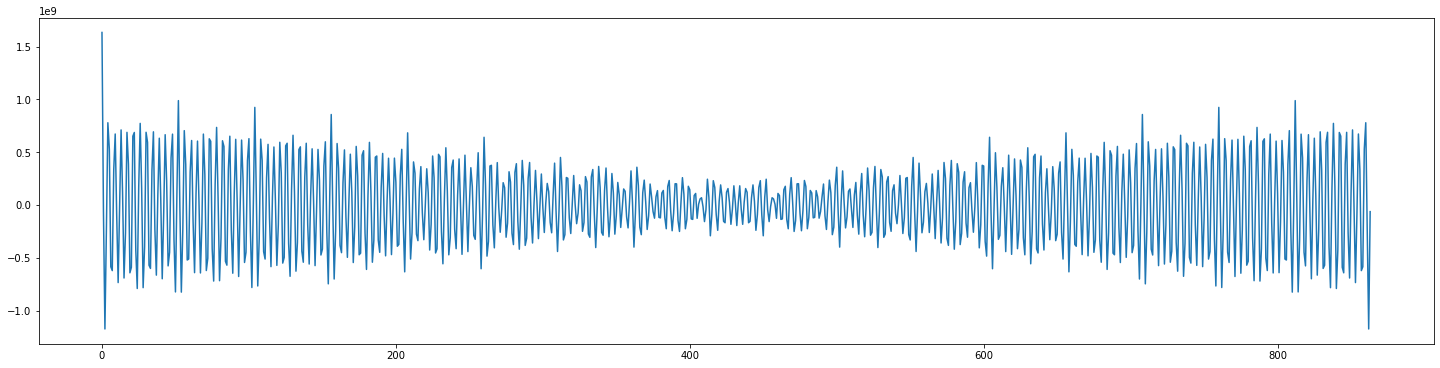

In [18]:
plt.figure(figsize=(25, 6))
plt.plot(total_r_p[90])

In [19]:
# p_t (180, img.shape[0])
# sinogram (img.shape[0], 180)

theta = sinogram.shape[1]
total_r_p = {}

for t in range(theta):
    p_t = deri_p_t[t]
    m = np.mean(p_t)
    r_p = []
    
    for k in range(len(p_t)//2):
        sum_ = 0
        for i in range(len(p_t)//2):
            sum_ += (p_t[(i+k)]-m)*(p_t[i]-m)
        r_p.append(sum_)   # k에 대하여 r_p (len(k), len(i))
        
    total_r_p[t]= r_p   # theta에 대하여 total_r_p {(theta): [(k),(i)]}

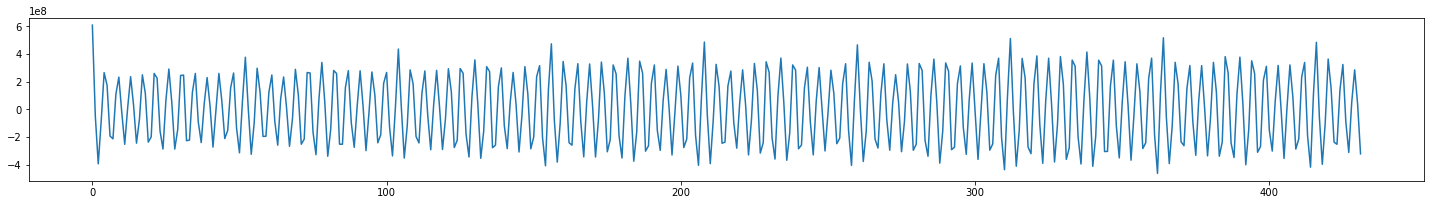

In [20]:
plt.figure(figsize=(25, 3))
plt.plot(total_r_p[90])

### 5. Fourier Transform

In [21]:
# f = np.fft.fft(total_r_p[30])
# plt.plot(f)

f = []

for t in range(theta):
    f.append(abs(np.fft.fft(total_r_p[t])))

In [22]:
# f_s = np.fft.fftshift(f)
# plt.plot(f_s)

f_s = []
for t in range(theta):
    f_s.append(np.fft.fftshift(f[t]))

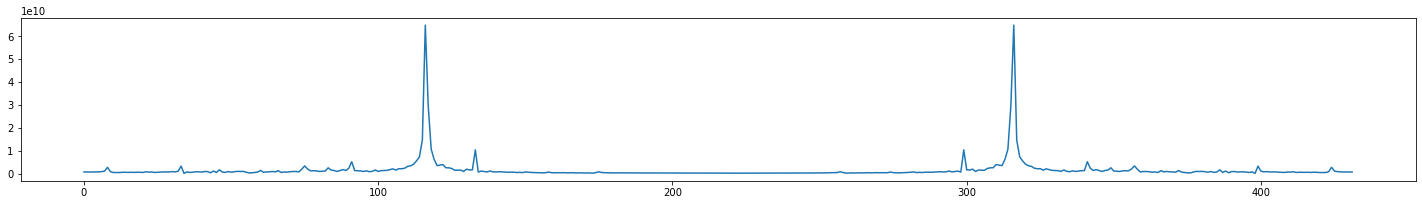

In [23]:
plt.figure(figsize=(25, 3))
plt.plot(f_s[90])

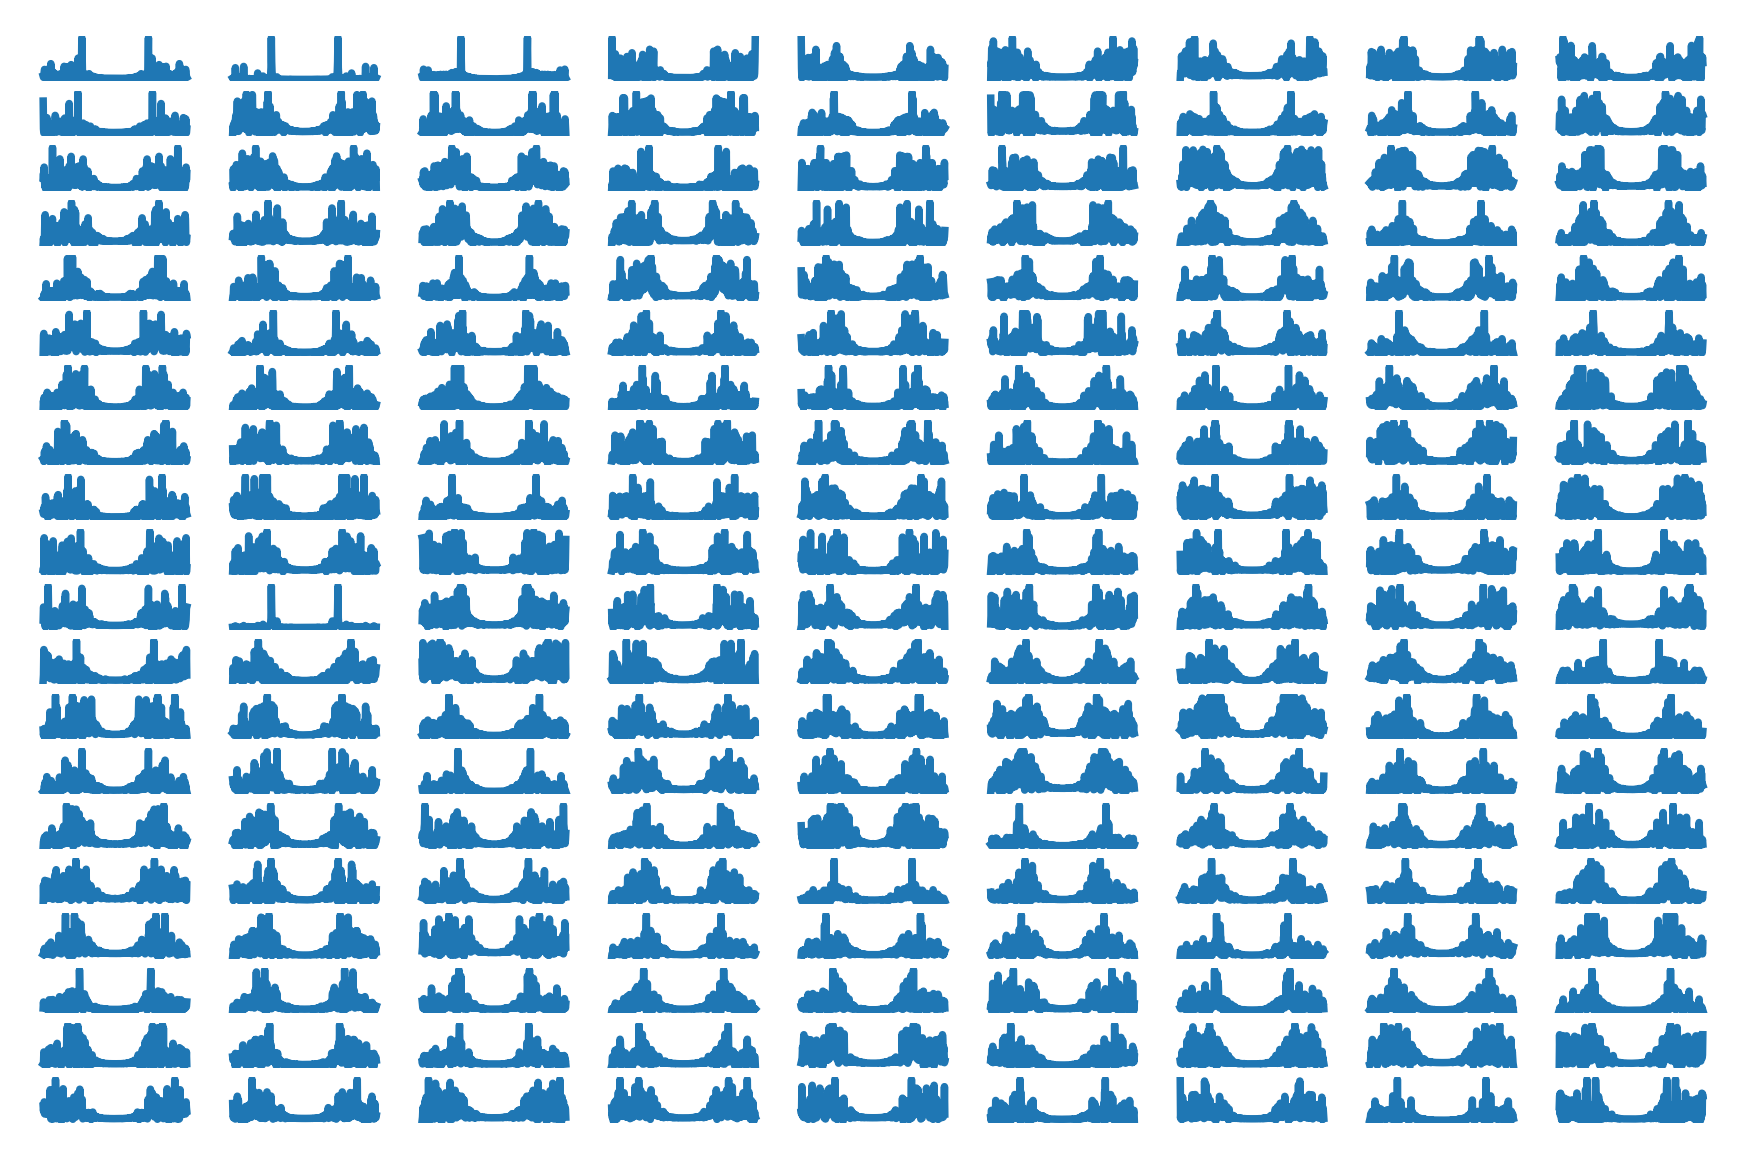

In [34]:
fig, ax = plt.subplots(20, 9, dpi=72*5)
size = 9

for t in range(theta):
    ax[t//size, t%size].plot(f_s[t-1])
    ax[t//size, t%size].axis('off')

plt.show()